# Function 5 Analysis - Week 3

This notebook contains the exploratory analysis for **Function 5** in Week 3. We continue to focus on an exploitation strategy around the best observed peak, now with **22 datapoints** after adding the last two weeks’ measurements.

**Function Description:** 	
You’re tasked with optimising a four-variable black-box function that represents the yield of a chemical process in a factory. The function is typically unimodal, with a single peak where yield is maximised. Your goal is to find the optimal combination of chemical inputs that delivers the highest possible yield, using systematic exploration and optimisation methods.

## Loading and Displaying the Data

We load the inputs and outputs for function 5 and display them in a table format to inspect the raw data values. The best outputs cluster around high x2–x4 and low x1. The Week 2 point from Bayesian optimization is now the global maximum at ≈1935, representing a significant improvement over previous observations and validating our optimization strategy.


In [ ]:
from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
sns.set_theme(style="ticks", context="notebook")
path = Path("../../initial_data/function_5")
X = np.load(path / "initial_inputs.npy")
y = np.load(path / "initial_outputs.npy")

# Week 1 and Week 2 new points
X_new_point_week_1 = np.array([[0.191447, 0.846480, 0.879484, 0.878516]])
y_new_point_week_1 = np.array([1086.3644542213872])
X_new_point_week_2 = np.array([[0.202624, 0.849188, 0.971974, 0.920186]])
y_new_point_week_2 = np.array([1935.0092608386958])

X = np.vstack([X, X_new_point_week_1, X_new_point_week_2])
y = np.concatenate([y, y_new_point_week_1, y_new_point_week_2])

df = pd.DataFrame(X, columns=["x1", "x2", "x3", "x4"]); df["y"] = y
display(df)
print("df sorted by y")
df_sorted = df.sort_values("y", ascending=False).reset_index(drop=True)
df_sorted["x_avg"] = df_sorted[["x1", "x2", "x3", "x4"]].mean(axis=1)
display(df_sorted)


,x1,x2,x3,x4,y
0,0.191447,0.038193,0.607418,0.414584,64.443440
1,0.758653,0.536518,0.656000,0.360342,18.301380
2,0.438350,0.804340,0.210245,0.151295,0.112940
3,0.706051,0.534192,0.264243,0.482088,4.210898
4,0.836478,0.193610,0.663893,0.785649,258.370525
5,0.683432,0.118663,0.829046,0.567577,78.434389
6,0.553621,0.667350,0.323806,0.814870,57.571537
7,0.352356,0.322242,0.116979,0.473113,109.571876
8,0.153786,0.729382,0.422598,0.443074,8.847992
9,0.463442,0.630025,0.107906,0.957644,233.223610


df sorted by y


,x1,x2,x3,x4,y,x_avg
0,0.202624,0.849188,0.971974,0.920186,1935.009261,0.735993
1,0.224189,0.846480,0.879484,0.878516,1088.859618,0.707167
2,0.191447,0.846480,0.879484,0.878516,1086.364454,0.698982
3,0.119879,0.862540,0.643331,0.849804,431.612757,0.618889
4,0.438933,0.774092,0.378167,0.933696,355.806818,0.631222
5,0.836478,0.193610,0.663893,0.785649,258.370525,0.619907
6,0.463442,0.630025,0.107906,0.957644,233.223610,0.539754
7,0.352356,0.322242,0.116979,0.473113,109.571876,0.316172
8,0.511142,0.817957,0.728710,0.112354,79.729130,0.542541
9,0.683432,0.118663,0.829046,0.567577,78.434389,0.549679


**Observations:**
- **Week 1:** The point `(0.191447, 0.846480, 0.879484, 0.878516)` yielded ≈1086, confirming we were near the peak
- **Week 2:** Following Bayesian optimization, the point `(0.202624, 0.849188, 0.971974, 0.920186)` yielded ≈**1935**, which is our new global maximum and represents a significant improvement
- Best outputs cluster around high x2–x4 (≈0.85–0.97) and low x1 (≈0.19–0.20)
- The function appears unimodal with a clear maximum region, and the Week 2 result validates our Bayesian optimization approach


## Feature Engineering and Correlation Analysis

We've observed that high y values correlate with high x2–x4 values. To validate this hypothesis and potentially improve our understanding, we create derived features that capture patterns in x2–x4:

**Aggregation Features:**
1. **Average of x2–x4** (`x234_avg`): Captures the overall level of x2, x3, x4
2. **Product of x2–x4** (`x234_prod`): Captures multiplicative interactions
3. **Range of x2–x4** (`x234_range`): Captures spread/variability (max - min)
4. **Standard deviation of x2–x4** (`x234_std`): Another measure of variability

**Difference Features:**
5. **Pairwise differences** (`x2_x4_diff`, `x2_x3_diff`, `x3_x4_diff`): Captures relative relationships between x2, x3, x4
6. **Sum of absolute pairwise differences** (`x234_diff_sum`): Captures overall variability/dispersion between x2, x3, x4

We compute correlations between these derived features and y to validate our hypothesis and identify the most informative feature transformations. If certain derived features show very strong correlations, this suggests the function may have a simpler structure than initially apparent.


In [26]:
# Create derived features
df_analysis = df.copy()

# Average of x2-x4
df_analysis["x234_avg"] = df_analysis[["x2", "x3", "x4"]].mean(axis=1)

# Product of x2-x4 (multiplicative interaction)
df_analysis["x234_prod"] = df_analysis["x2"] * df_analysis["x3"] * df_analysis["x4"]

# Range of x2-x4 (max - min)
df_analysis["x234_range"] = df_analysis[["x2", "x3", "x4"]].max(axis=1) - df_analysis[["x2", "x3", "x4"]].min(axis=1)

# Standard deviation of x2-x4
df_analysis["x234_std"] = df_analysis[["x2", "x3", "x4"]].std(axis=1)

# Pairwise differences between x2, x3, x4
df_analysis["x2_x4_diff"] = df_analysis["x2"] - df_analysis["x4"]
df_analysis["x2_x3_diff"] = df_analysis["x2"] - df_analysis["x3"]
df_analysis["x3_x4_diff"] = df_analysis["x3"] - df_analysis["x4"]

# Sum of absolute pairwise differences
df_analysis["x234_diff_sum"] = (df_analysis["x2_x4_diff"].abs() + 
                                 df_analysis["x2_x3_diff"].abs() + 
                                 df_analysis["x3_x4_diff"].abs())

# Compute correlations with y
correlation_features = ["x1", "x2", "x3", "x4", 
                       "x234_avg", "x234_prod", "x234_range", "x234_std",
                       "x2_x4_diff", "x2_x3_diff", "x3_x4_diff", "x234_diff_sum"]
correlations = df_analysis[correlation_features + ["y"]].corr()["y"].sort_values(ascending=False)

print("Correlations with y (sorted by absolute value):")
print("=" * 60)
for feat in correlations.index:
    if feat != "y":
        print(f"{feat:15s}: {correlations[feat]:7.4f}")

# Display highest correlation
print("\n" + "=" * 60)
print("Highest correlation with y:")
print("=" * 60)
top_feature = correlations.drop("y").abs().idxmax()
print(f"{top_feature:15s}: {correlations[top_feature]:7.4f}")


Correlations with y (sorted by absolute value):
x234_prod      :  0.9254
x234_avg       :  0.8210
x4             :  0.5772
x3             :  0.5762
x2             :  0.4829
x2_x3_diff     : -0.0537
x3_x4_diff     : -0.0682
x2_x4_diff     : -0.1389
x1             : -0.4091
x234_range     : -0.6039
x234_diff_sum  : -0.6039
x234_std       : -0.6082

Highest correlation with y:
x234_prod      :  0.9254


## Visualization of x234_prod

We visualize the relationship between `x234_prod` (product of x2, x3, x4) and y, which shows the highest correlation (≈0.93) among all features.


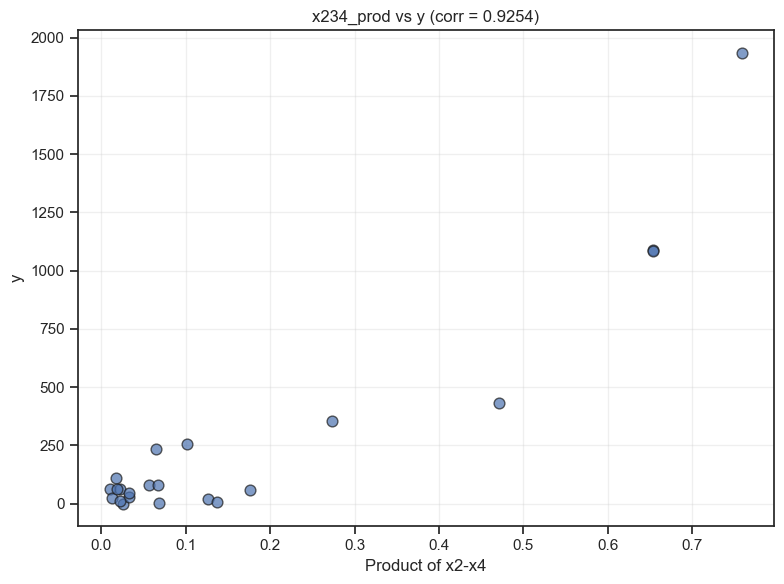

In [27]:
# Visualize x234_prod vs y
plt.figure(figsize=(8, 6))
plt.scatter(df_analysis["x234_prod"], df_analysis["y"], alpha=0.7, edgecolors='k', s=60)
plt.xlabel("Product of x2-x4")
plt.ylabel("y")
plt.title(f"x234_prod vs y (corr = {correlations['x234_prod']:.4f})")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Insights from Feature Engineering

Based on the correlation analysis:

1. **Strongest correlation**: `x234_prod` (product of x2, x3, x4) shows the highest correlation with y (≈0.93), indicating strong predictive power and suggesting the function has a simpler structure than initially apparent.

2. **Interpretation**: The very high correlation (>0.9) suggests:
   - The function is well-characterized by the product of x2, x3, x4
   - The optimal region corresponds to high values of `x234_prod`
   - We can use this insight to constrain our search space

3. **Application**: Rather than adding `x234_prod` as a redundant GP feature (since it's deterministic from x2, x3, x4), we use it to constrain the optimization by penalizing regions where `x234_prod` is below the 75th percentile of observed values.


In [28]:
# Use x234_prod (highest correlation) to constrain search space
best_feature = "x234_prod"
feature_threshold = df_analysis["x234_prod"].quantile(0.75)

print("=" * 60)
print("Constraint Setup")
print("=" * 60)
print(f"Using {best_feature} (correlation = {correlations['x234_prod']:.4f})")
print(f"Threshold (75th percentile): {feature_threshold:.4f}")
print(f"Constraint: {best_feature} >= {feature_threshold:.4f}")
print("=" * 60)


Constraint Setup
Using x234_prod (correlation = 0.9254)
Threshold (75th percentile): 0.1662
Constraint: x234_prod >= 0.1662


## Gaussian Process Model for Exploitation

We fit a Gaussian Process regressor on the original 4D space (x1, x2, x3, x4). **Note:** We don't add `x234_prod` as an input since it's redundant (the GP can learn it from x2, x3, x4). Instead, we use the correlation insight to **constrain the search space** during optimization, focusing on regions where `x234_prod` is high (above the 75th percentile). For exploitation, we focus on maximizing the **GP mean prediction** rather than exploration metrics like UCB. This strategy is appropriate because:
- We've confirmed the function is unimodal with a single peak
- Our recent measurements validate we're near the optimum (Week 2 found a new maximum at ≈1935)
- The `x234_prod` constraint helps focus the search on promising high-yield regions
- Exploitation allows us to refine our estimate of the peak location


In [29]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel
from sklearn.preprocessing import StandardScaler

# Standardize inputs and outputs for better GP performance
# Keep GP on original 4D space (x1, x2, x3, x4) - no redundant features
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

# Define kernel: Matern with nu=2.5 (smooth but not infinitely differentiable)
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5)

# Fit GP
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-6, normalize_y=False)
gp.fit(X_scaled, y_scaled)

print(f"GP fitted on 4D space (x1, x2, x3, x4)")
print(f"Using {best_feature} constraint (>= {feature_threshold:.4f}) to guide search")
print(f"Optimized kernel: {gp.kernel_}")
print(f"Log-marginal-likelihood: {gp.log_marginal_likelihood(gp.kernel_.theta):.2f}")


GP fitted on 4D space (x1, x2, x3, x4)
Using x234_prod constraint (>= 0.1662) to guide search
Optimized kernel: 0.862**2 * Matern(length_scale=0.481, nu=2.5)
Log-marginal-likelihood: -26.60


## Bayesian Optimization with Constraint

We use Bayesian optimization to find the next point to evaluate. The optimization maximizes the GP mean prediction (pure exploitation) while using a **soft constraint** based on `x234_prod`. 

**How the constraint works:** The constraint is applied **during optimization**, not as a post-filter. The objective function is modified to penalize points where `x234_prod < threshold` (by adding a large penalty to the objective value). This actively guides the optimizer's search toward high `x234_prod` regions, rather than simply filtering candidates after the acquisition function has run. The optimizer naturally avoids regions with low `x234_prod` because they have worse (higher) objective values.

This approach leverages our insight that `x234_prod` strongly correlates with y (correlation ≈ 0.93) without adding redundant features to the GP model.

In [30]:
from scipy.optimize import differential_evolution

# Define objective: negative GP mean (to maximize mean, we minimize negative mean)
# Use constraint based on x234_prod to focus search
def negative_gp_mean(x):
    # Compute x234_prod from x2, x3, x4
    x234_prod_val = x[1] * x[2] * x[3]
    
    # Penalize if x234_prod is below threshold (soft constraint)
    # This guides the search towards high x234_prod regions
    penalty = 0.0
    if x234_prod_val < feature_threshold:
        penalty = 1000.0 * (feature_threshold - x234_prod_val)  # Large penalty for low values
    
    # Predict with GP (on 4D space)
    x_scaled = scaler_X.transform(x.reshape(1, -1))
    mu_scaled = gp.predict(x_scaled, return_std=False)
    mu = scaler_y.inverse_transform(mu_scaled.reshape(-1, 1)).ravel()[0]
    return -mu + penalty

# Optimize over [0, 1]^4 with constraint
bounds = [(0, 1)] * 4
result = differential_evolution(negative_gp_mean, bounds, seed=42, maxiter=1000, atol=1e-7, tol=1e-7)

# Extract recommended point
x_next = result.x

# Get actual GP prediction (without penalty)
x_next_scaled = scaler_X.transform(x_next.reshape(1, -1))
mu_scaled = gp.predict(x_next_scaled, return_std=False)
y_next_pred = scaler_y.inverse_transform(mu_scaled.reshape(-1, 1)).ravel()[0]

# Compute x234_prod for the recommended point
x234_prod_next = x_next[1] * x_next[2] * x_next[3]

print("=" * 60)
print(f"RECOMMENDED NEXT POINT (Pure Exploitation via GP Mean)")
print(f"Search constrained by x234_prod >= {feature_threshold:.4f}")
print("=" * 60)
print(f"x1 = {x_next[0]:.6f}")
print(f"x2 = {x_next[1]:.6f}")
print(f"x3 = {x_next[2]:.6f}")
print(f"x4 = {x_next[3]:.6f}")
print(f"x234_prod = {x234_prod_next:.6f} {'✓' if x234_prod_next >= feature_threshold else '⚠ (below threshold)'}")
print(f"\nPredicted output: {y_next_pred:.2f}")
print(f"Current best observed: {y.max():.2f} (at observation {y.argmax()})")
print("=" * 60)


RECOMMENDED NEXT POINT (Pure Exploitation via GP Mean)
Search constrained by x234_prod >= 0.1662
x1 = 0.203491
x2 = 0.849529
x3 = 0.982723
x4 = 0.925116
x234_prod = 0.772335 ✓

Predicted output: 1948.72
Current best observed: 1935.01 (at observation 21)


## Summary

**Strategy:** Pure exploitation via GP mean maximization with `x234_prod` constraint

**Key Insights:**
- Correlation analysis shows `x234_prod` (product of x2, x3, x4) has the highest correlation with y (≈0.93)
- This suggests the function has a simpler structure than initially apparent
- Rather than adding redundant features to the GP, we use this insight to constrain the search space

**Approach:**
- GP model stays on original 4D space (x1, x2, x3, x4) - no redundant features
- Optimization uses soft constraint: penalizes regions where `x234_prod < threshold` (75th percentile of observed values)
- This guides search toward promising high-yield regions without adding unnecessary complexity

**Rationale:**
- Function 5 is confirmed unimodal with a single peak
- We have 22 observations with several near the optimum (Week 2 found new maximum at ≈1935)
- The `x234_prod` constraint helps focus the search on high-yield regions
- Maximizing the GP mean prediction focuses sampling precisely where the model predicts the highest yield

**Next Steps:**
- Submit the recommended point above
- Continue exploitation in subsequent weeks to refine the peak estimate
- Monitor if predictions remain accurate as we gather more data
